In [2]:
import pandas as pd
import numpy as np
import pymysql
from typing import Dict, List, Tuple, Optional
from DATA.stock_invest_function import get_db_host

In [3]:
def get_indicator_list_from_db(db_info: Dict,
                               table_name: str = "us_required_return_result"
                               ) -> List[str]:
    """
    큰 테이블 전체를 읽지 않고,
    DB에서 DISTINCT indicator 이름만 추출.
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    query = f"SELECT DISTINCT indicator FROM {table_name};"

    try:
        df = pd.read_sql(query, conn)
    finally:
        conn.close()

    return sorted(df["indicator"].dropna().tolist())

def fetch_required_return_pivot_from_db(
    db_info: Dict,
    table_name: str = "us_required_return_result",
    indicators: Optional[List[str]] = None,
    start_date: Optional[str] = None,   # "YYYY-MM-DD"
    end_date: Optional[str] = None,     # "YYYY-MM-DD"
    tickers: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    us_required_return_result 테이블에서 직접 pivot 형태로 SELECT.

    - index: date, ticker
    - columns: indicator 이름들
    - values: value (MAX(CASE WHEN ...) 사용)

    큰 테이블 전체를 안 읽고, SQL에서 집계해서 가져오기 때문에 메모리 부담이 훨씬 적다.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 1) indicator 리스트가 안 들어오면, DB에서 DISTINCT로 먼저 가져오기
        if indicators is None:
            indicators = get_indicator_list_from_db(db_info, table_name)

        # 2) indicator별 CASE WHEN 절 만들기
        case_clauses = []
        for ind in indicators:
            # 컬럼 alias에 공백/특수문자가 있으면 쿼리가 깨질 수 있으므로 간단히 감싸줌
            safe_alias = ind.replace("`", "")  # 백틱 제거
            clause = f"MAX(CASE WHEN indicator = %s THEN value END) AS `{safe_alias}`"
            case_clauses.append(clause)

        case_sql = ",\n       ".join(case_clauses)

        # 3) WHERE 절 동적으로 생성
        where_clauses = []
        params = []

        if start_date is not None:
            where_clauses.append("date >= %s")
            params.append(start_date)

        if end_date is not None:
            where_clauses.append("date <= %s")
            params.append(end_date)

        if tickers is not None and len(tickers) > 0:
            # IN (%s, %s, ...)
            tick_placeholders = ", ".join(["%s"] * len(tickers))
            where_clauses.append(f"ticker IN ({tick_placeholders})")
            params.extend(tickers)

        where_sql = ""
        if where_clauses:
            where_sql = "WHERE " + " AND ".join(where_clauses)

        # 4) 전체 쿼리 조립
        #    date, ticker별로 indicator를 열로 펼친 형태
        query = f"""
            SELECT
                date,
                ticker,
                {case_sql}
            FROM {table_name}
            {where_sql}
            GROUP BY date, ticker
            ORDER BY date, ticker;
        """

        # indicator 값들을 CASE WHEN의 %s에 넣어줌
        # CASE WHEN indicator = %s THEN value END  → 각 indicator마다 하나씩
        case_params = indicators[:]  # 각 CASE WHEN 한 번씩
        all_params = case_params + params

        df_pivot = pd.read_sql(query, conn, params=all_params)

        # date를 datetime으로 변환 (필요시)
        df_pivot["date"] = pd.to_datetime(df_pivot["date"])
        return df_pivot

    finally:
        conn.close()


def fetch_sec_financial_item_pivot(
    db_info: Dict,
    item_name: str,
    table_name: str = "sec_financial_data",
    tickers: Optional[List[str]] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None
) -> pd.DataFrame:
    """
    sec_financial_data 테이블에서 item_name과 ticker를 입력하면
    date | ticker | <item_name> 형태의 pivot-like DataFrame을 반환.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 1. 동적 WHERE 조건 생성
        where_clauses = ["item_name = %s"]
        params: List = [item_name]

        if tickers:
            placeholders = ", ".join(["%s"] * len(tickers))
            where_clauses.append(f"ticker IN ({placeholders})")
            params.extend(tickers)

        if start_date:
            where_clauses.append("date >= %s")
            params.append(start_date)

        if end_date:
            where_clauses.append("date <= %s")
            params.append(end_date)

        where_sql = "WHERE " + " AND ".join(where_clauses)

        # 2. SQL 실행
        query = f"""
            SELECT
                date,
                ticker,
                value
            FROM {table_name}
            {where_sql}
            ORDER BY date, ticker;
        """

        df = pd.read_sql(query, conn, params=params)

    finally:
        conn.close()

    # 빈 데이터 처리
    if df.empty:
        print(f"[WARN] No data for item_name={item_name}, tickers={tickers}")
        return df

    # date 컬럼을 datetime 형태로 변환
    df["date"] = pd.to_datetime(df["date"])

    # value → item_name 으로 컬럼명 변경
    df = df.rename(columns={"value": item_name})

    # pivot-like format 유지
    df = df[["date", "ticker", item_name]]

    return df


def get_top_tickers_by_latest_item(
    db_info: Dict,
    item_name: str,
    top_n: int = 20,
    table_name: str = "sec_financial_data",
) -> pd.DataFrame:
    """
    sec_financial_data 테이블에서
    - 특정 item_name에 대해
    - ticker별 '가장 최근 date'의 value를 가져오고
    - value가 큰 순서대로 상위 top_n개를 반환.

    반환 컬럼: rank, ticker, item_name, date, value
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        # 서브쿼리로 ticker별 최신 날짜 구하고 join
        query = f"""
            SELECT
                s.ticker,
                s.item_name,
                s.date,
                s.value
            FROM {table_name} AS s
            JOIN (
                SELECT
                    ticker,
                    MAX(date) AS max_date
                FROM {table_name}
                WHERE item_name = %s
                GROUP BY ticker
            ) AS t
              ON s.ticker = t.ticker
             AND s.date   = t.max_date
            WHERE s.item_name = %s
            ORDER BY s.value DESC
            LIMIT %s;
        """

        params = (item_name, item_name, top_n)
        df = pd.read_sql(query, conn, params=params)

    finally:
        conn.close()

    if df.empty:
        print(f"[WARN] item_name={item_name} 에 해당하는 데이터가 없습니다.")
        return df

    # rank 컬럼 추가 (1위부터)
    df.insert(0, "rank", range(1, len(df) + 1))

    # date를 datetime으로 변환(원하시면)
    df["date"] = pd.to_datetime(df["date"])

    return df

In [4]:
# 1) DB 설정
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",   # 실제 비밀번호
    "database": "investar",
}

In [5]:
indicators = get_indicator_list_from_db(db_info, "us_required_return_result")
print("indicator 목록:", indicators)

indicator 목록: ['Re_1y', 'Re_3y', 'Re_5y', 'beta_1250', 'beta_252', 'beta_750']


In [152]:
tickers = ['KLAC']

re_df = fetch_required_return_pivot_from_db(
    db_info=db_info,
    table_name="us_required_return_result",
    indicators=['Re_5y'],        # ← 리스트로!
    start_date="2020-01-01",
    end_date=None,
    tickers=tickers
)

print(re_df.head())

        date ticker     Re_5y
0 2020-01-02   KLAC  0.132117
1 2020-01-03   KLAC  0.133323
2 2020-01-06   KLAC  0.130630
3 2020-01-07   KLAC  0.129422
4 2020-01-08   KLAC  0.129305


In [153]:
# 예: Re_5y indicator 만 가져오기
roe_df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name="roe",
    tickers=tickers,
    start_date="2020-01-01"
)

roe_df['roe'] = roe_df['roe']/100

In [154]:
roe_re_df = pd.merge(roe_df, re_df, on=["ticker", "date"], how="left").dropna(axis=0, how="any")
roe_re_df['ri_rate'] = roe_re_df['roe'] - roe_re_df['Re_5y']


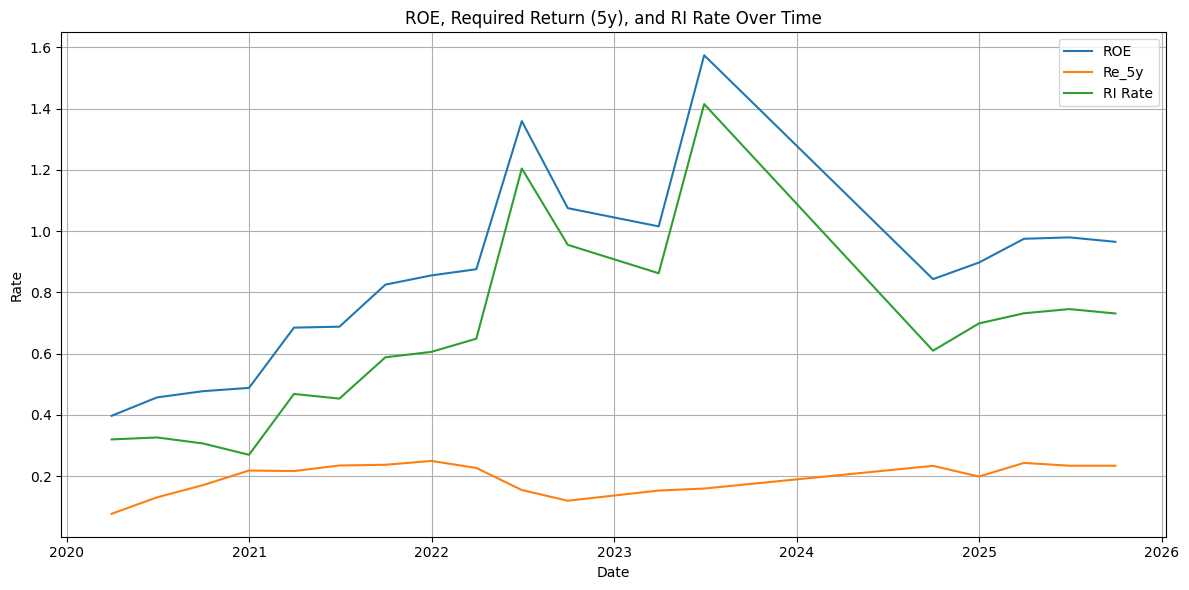

In [155]:
import matplotlib.pyplot as plt

# date를 datetime으로 변환 (안 되어 있을 경우 대비)
roe_re_df['date'] = pd.to_datetime(roe_re_df['date'])
# index 설정
df_plot = roe_re_df.set_index('date').sort_index()

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['roe'], label='ROE')
plt.plot(df_plot.index, df_plot['Re_5y'], label='Re_5y')
plt.plot(df_plot.index, df_plot['ri_rate'], label='RI Rate')

plt.title('ROE, Required Return (5y), and RI Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [135]:
# roe_top_df = get_top_tickers_by_latest_item(
#     db_info=db_info,
#     item_name="roe",  # 원하는 재무 항목
#     top_n=200                       # 상위 30개까지
# )


<AxesSubplot: >

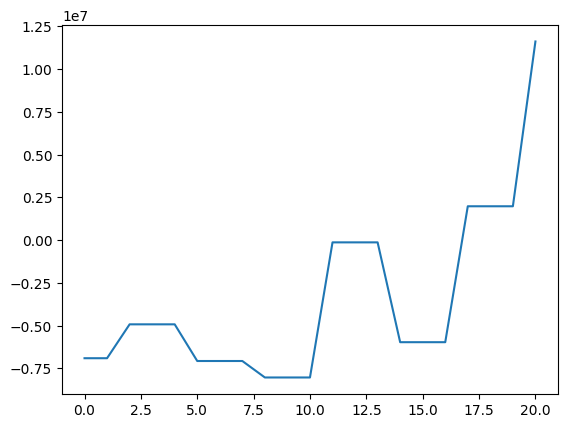

In [57]:
# 예: Re_5y indicator 만 가져오기
df = fetch_sec_financial_item_pivot(
    db_info=db_info,
    item_name="net_income",
    tickers=["SLGL"],
    start_date="2010-01-01"
)

df['net_income'].plot()